In [1]:
import os
os.chdir("../../..")

In [2]:
import torch
from models.DeepCNN import DeepCNN
from models.RamanFormer import RamanFormer
from models.RamanNet import RamanNet
from models.SANet import ScaleAdaptiveNet
from models.transformer import ViT
from torch.utils.data import Dataset,DataLoader
import pickle
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import numpy as np
from torch.utils.data import random_split
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
class Bacteria_Dataset(Dataset):
    def __init__(self,X_path,y_path,num_classes=30):
        """
        X_path is a string containing the path to the spectra
        y_path is a string containing the path to the labels for the spectra
        num_classes is an integer corresponding to an 8 class or 30 class problem 
        """
        super().__init__()
        self.X = np.load(X_path)
        self.y = np.load(y_path)
        self.num_classes = num_classes
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self,index):
        data = torch.Tensor(self.X[index]).unsqueeze(0) #of shape (1,1000)
        data = (data-data.min())/(data.max()-data.min())
        label = self.y[index]
        if self.num_classes==8:
            label = ATCC_GROUPINGS[label]
        return data,int(label)

In [4]:
def conf_matrix_DL(model,device,test_dataloader,num_classes):
    model.eval()
    loop = tqdm(test_dataloader)
    labels = np.arange(num_classes)

    matrix = np.zeros((num_classes,num_classes))

    with torch.no_grad():
        for i, (X, y) in enumerate(loop):
            X = X.to(device)

            y_pred = model(X) #of shape (b,num_classes)                  
            preds = y_pred.argmax(dim=1) #of shape (b)
            matrix += confusion_matrix(y,preds.cpu(),labels=labels) #Row is GT and column is prediction

    return matrix

In [5]:
def conf_matrix_RamanNet(model,device,test_dataloader,num_classes):
    model.eval()
    loop = tqdm(test_dataloader)
    labels = np.arange(num_classes)

    matrix = np.zeros((num_classes,num_classes))

    with torch.no_grad():
        for i, (X, y) in enumerate(loop):
            X = X.to(device)

            y_pred,_ = model(X) #of shape (b,num_classes)                  
            preds = y_pred.argmax(dim=1) #of shape (b)
            matrix += confusion_matrix(y,preds.cpu(),labels=labels) #Row is GT and column is prediction

    return matrix

In [6]:
def conf_matrix_ML(model,test_set,num_classes):
    X_test = [test_set[i][0].squeeze() for i in range(len(test_set))]
    y_test = [test_set[i][1] for i in range(len(test_set))]
    labels = np.arange(num_classes)

    all_preds = model.predict(X_test)
    all_preds = np.array(all_preds)
    all_targets = np.array(y_test)

    matrix = confusion_matrix(all_targets,all_preds,labels=labels) #Row is GT and column is prediction

    return matrix

In [7]:
def conf_matrix_Random(test_set,train_set,num_classes):
    y_test = [test_set[i][1] for i in range(len(test_set))]
    y_train = [train_set[i][1] for i in range(len(train_set))]
    classes = sorted(list(set(y_train)))
    labels = np.arange(num_classes)

    rng = np.random.default_rng(1)
    all_preds = rng.choice(classes,len(y_test))

    all_targets = np.array(y_test)

    matrix = confusion_matrix(all_targets,all_preds,labels=labels) #Row is GT and column is prediction
    
    return matrix

In [8]:
def conf_matrix_majority(test_set,all_train_set,num_classes=32):
    y_test = [test_set[i][1] for i in range(len(test_set))]

    generator = torch.manual_seed(43)
    train_set, _ = random_split(all_train_set,[0.8,0.2],generator=generator)
    y_train = [train_set[i][1] for i in range(len(train_set))]
    labels = np.arange(num_classes)

    count = {}
    max_freq = 0
    max_class = None

    for y in y_train:
        if y not in count:
            count[y] = 1
        
        else:
            count[y] += 1
        
        if count[y]>max_freq:
            max_freq = count[y]
            max_class = y
    

    all_preds = np.array([max_class for _ in range(len(y_test))])

    all_targets = np.array(y_test)

    matrix = confusion_matrix(all_targets,all_preds,labels=labels) #Row is GT and column is prediction

    return matrix

In [9]:
def normalize(matrix):
    row_sums = matrix.sum(axis=1, keepdims=True)
    norm = np.divide(matrix,row_sums,where=row_sums!=0,out=np.zeros_like(matrix, dtype=float))
    return norm

In [10]:
def all_conf(model3,model4,model5,model6,model7,model8,model9,device,test_dataloader,train_set,num_classes):
    m1 = normalize(conf_matrix_Random(test_dataloader.dataset,train_set,num_classes))
    m2 = normalize(conf_matrix_majority(test_dataloader.dataset,train_set,num_classes))
    m3 = normalize(conf_matrix_ML(model3,test_dataloader.dataset,num_classes))
    m4 = normalize(conf_matrix_ML(model4,test_dataloader.dataset,num_classes))
    m5 = normalize(conf_matrix_DL(model5,device,test_dataloader,num_classes))
    m6 = normalize(conf_matrix_DL(model6,device,test_dataloader,num_classes))
    m7 = normalize(conf_matrix_RamanNet(model7,device,test_dataloader,num_classes))
    m8 = normalize(conf_matrix_DL(model8,device,test_dataloader,num_classes))
    m9 = normalize(conf_matrix_DL(model9,device,test_dataloader,num_classes))


    fig, axes = plt.subplots(3, 3, figsize=(45, 36))

    sns.heatmap(m1, ax=axes[0][0], annot=False)
    axes[0][0].set_title("Random Classifier",fontsize=28)

    sns.heatmap(m2, ax=axes[0][1], annot=False)
    axes[0][1].set_title("Majority Class Classifier",fontsize=28)

    sns.heatmap(m3, ax=axes[0][2], annot=False)
    axes[0][2].set_title("Random Forest",fontsize=28)

    sns.heatmap(m4, ax=axes[1][0], annot=False)
    axes[1][0].set_title("SVC",fontsize=28)

    sns.heatmap(m5, ax=axes[1][1], annot=False)
    axes[1][1].set_title("Deep CNN",fontsize=28)

    sns.heatmap(m6, ax=axes[1][2], annot=False)
    axes[1][2].set_title("SANet",fontsize=28)

    sns.heatmap(m7, ax=axes[2][0], annot=False)
    axes[2][0].set_title("RamanNet",fontsize=28)

    sns.heatmap(m8, ax=axes[2][1], annot=False)
    axes[2][1].set_title("Transformer",fontsize=28)

    sns.heatmap(m9, ax=axes[2][2], annot=False)
    axes[2][2].set_title("RamanFormer",fontsize=28)

    plt.show()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [12]:
train_set = Bacteria_Dataset("datasets/Bacteria_ID/X_finetune.npy","datasets/Bacteria_ID/y_finetune.npy",30)

test_set = Bacteria_Dataset("datasets/Bacteria_ID/X_test.npy","datasets/Bacteria_ID/y_test.npy",30)
test_loader = DataLoader(test_set, batch_size=32, num_workers=8,shuffle=False)
print(f"The number of elements in the test set is {len(test_loader.dataset)}")

The number of elements in the test set is 3000


In [13]:
deepcnn1 = DeepCNN(num_classes=30,sp_size=1000).to(device)
deepcnn1.load_state_dict(torch.load("results/final_multi_run/trained_models/Bacteria_ID_thirty_deepcnn_fine_0_15_90.5_.pt",weights_only=True))

RamanFormer1 = RamanFormer(num_classes=30,sp_size=1000,patch_size=125).to(device)
RamanFormer1.load_state_dict(torch.load("results/final_multi_run/trained_models/Bacteria_ID_thirty_RamanFormer_fine_0_37_92.0_.pt",weights_only=True))

RamanNet1 = RamanNet(num_classes=30,sp_size=1000).to(device)
RamanNet1.load_state_dict(torch.load("results/final_multi_run/trained_models/Bacteria_ID_thirty_RamanNet_fine_0_36_87.67_.pt",weights_only=True))

SANet1 = ScaleAdaptiveNet(num_classes=30).to(device)
SANet1.load_state_dict(torch.load("results/final_multi_run/trained_models/Bacteria_ID_thirty_SANet_fine_0_36_90.83_.pt",weights_only=True))

transformer1 = ViT(patch_size=125,p=0.1,num_classes=30).to(device)
transformer1.load_state_dict(torch.load("results/final_multi_run/trained_models/Bacteria_ID_thirty_transformer_fine_0_23_91.83_.pt",weights_only=True))

with open('results/final_multi_run/trained_models/Bacteria_ID_thirty_RandomForest_0_71.5_.pkl', 'rb') as file:
    randomforest1 = pickle.load(file)

with open('results/final_multi_run/trained_models/Bacteria_ID_thirty_SVC_0_91.17_.pkl', 'rb') as file:
    svc1 = pickle.load(file)

100%|██████████| 94/94 [00:00<00:00, 186.99it/s]


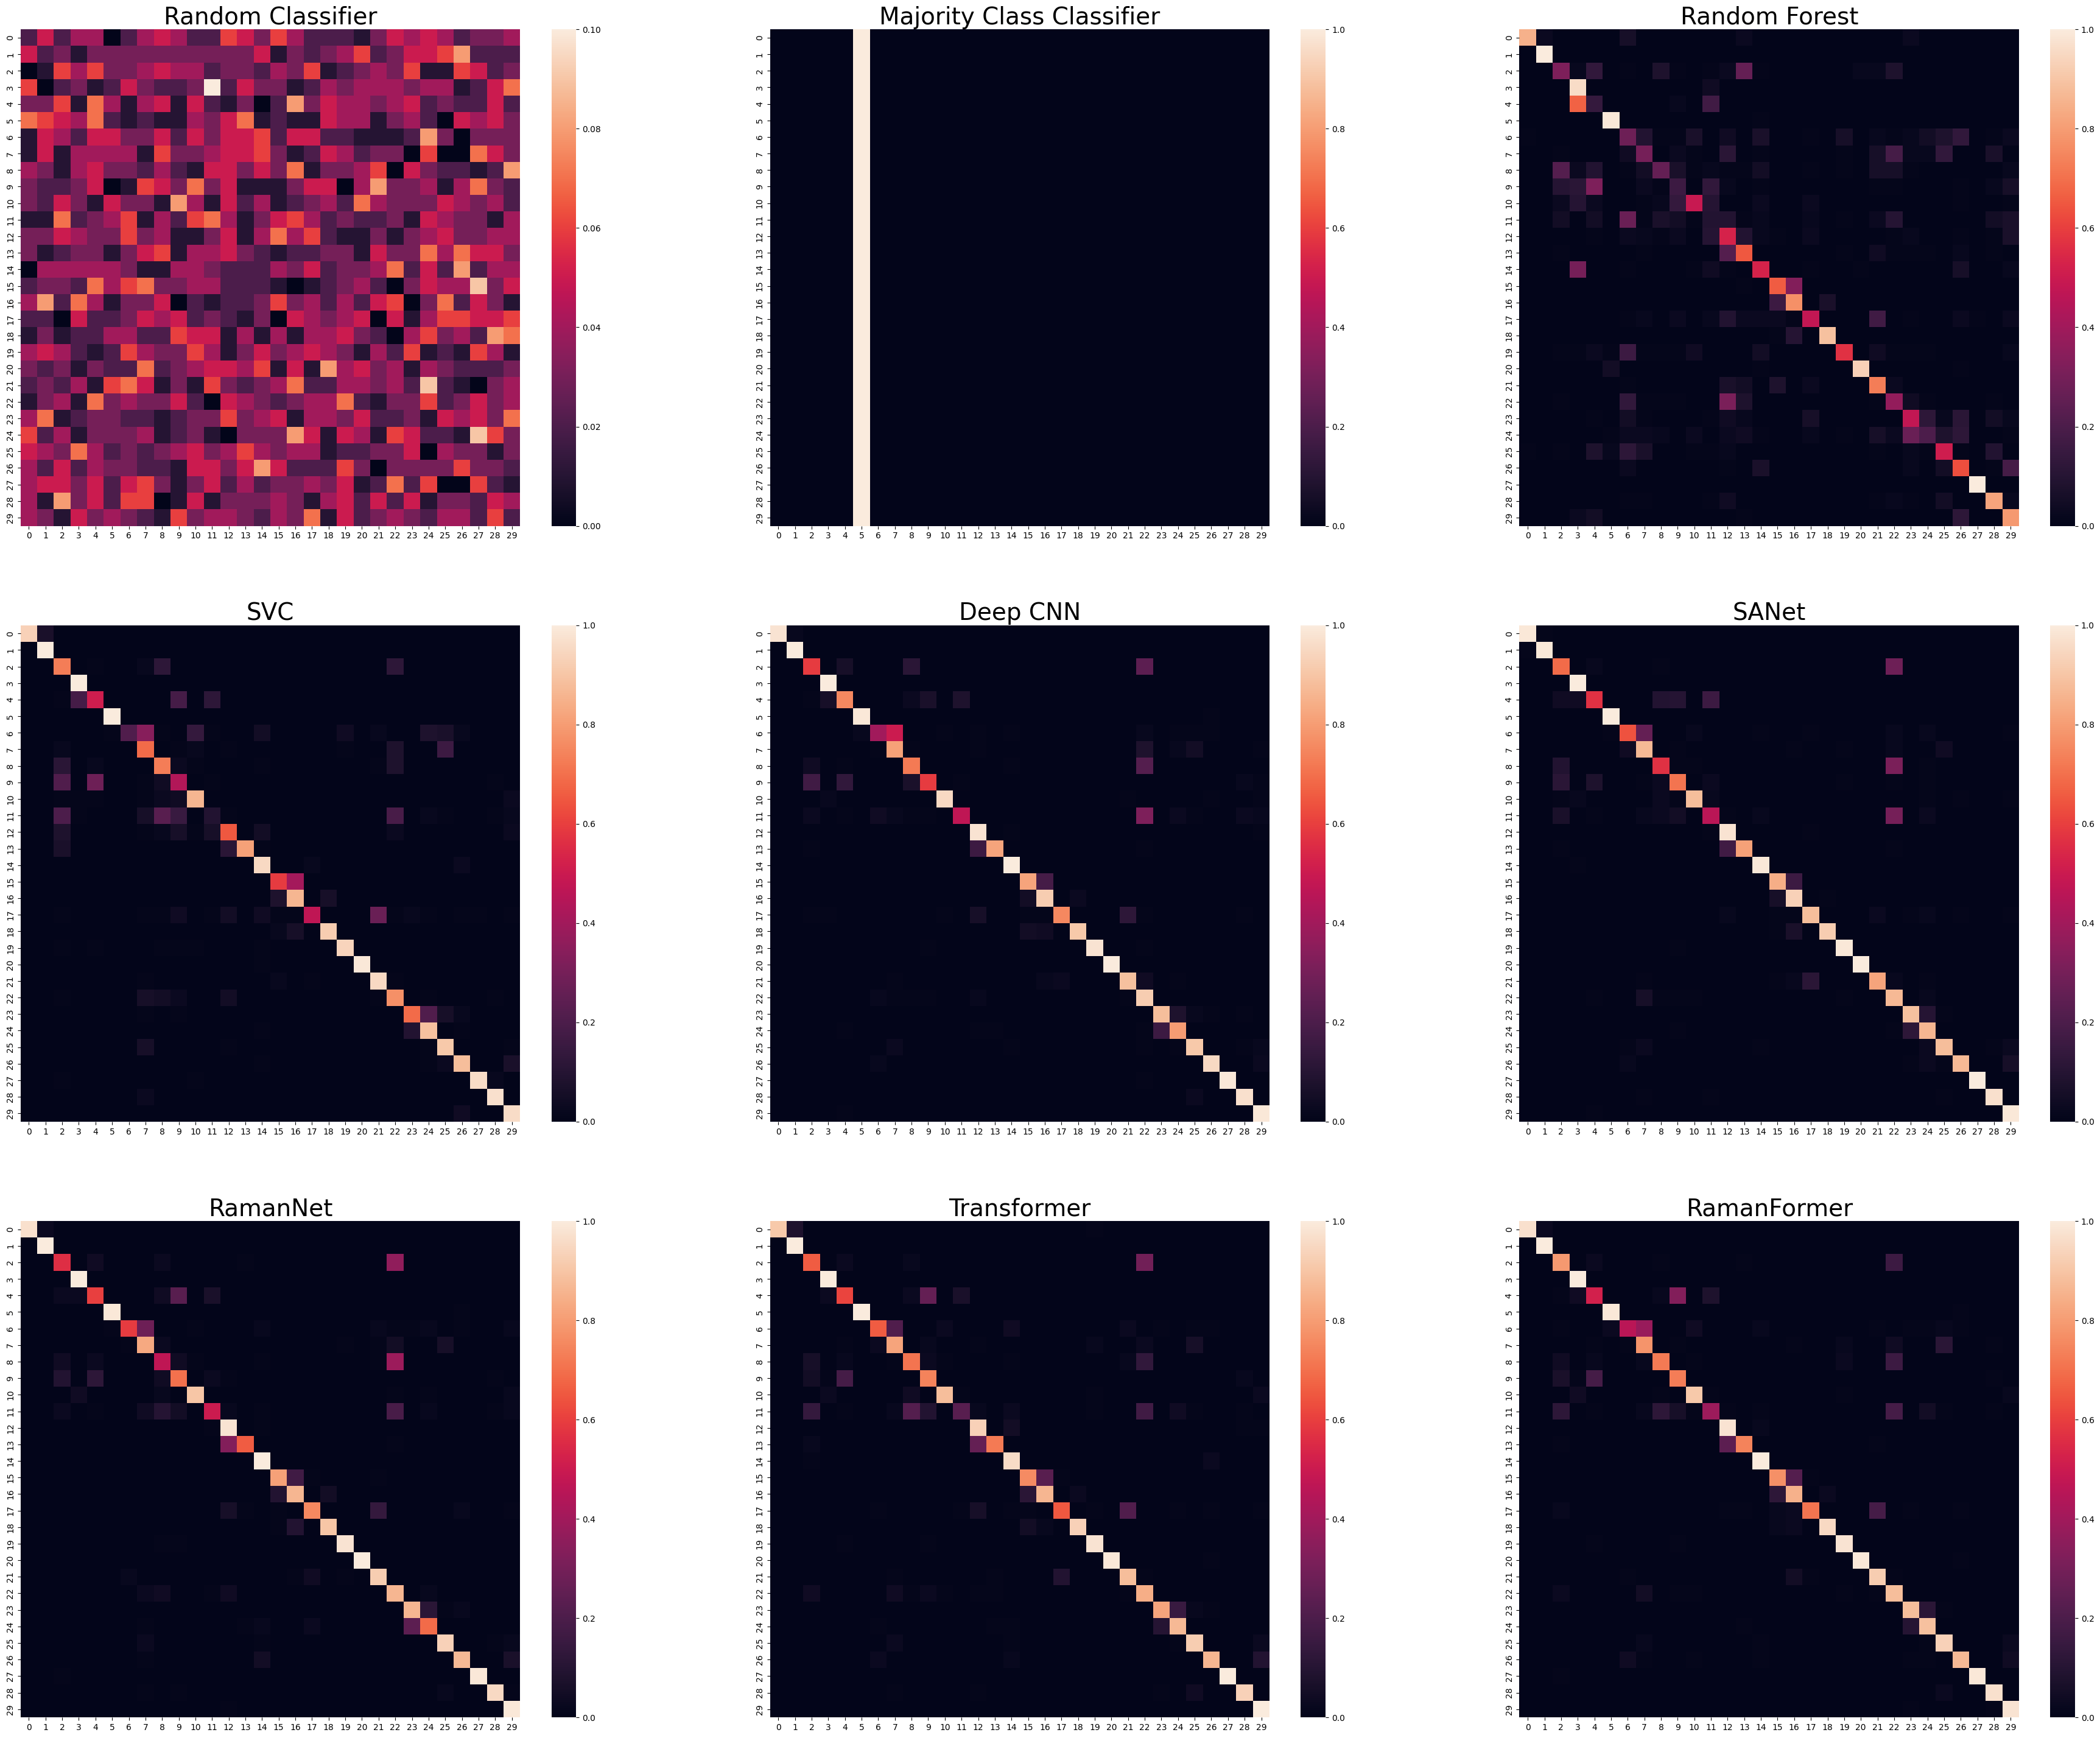

In [14]:
all_conf(randomforest1,svc1,deepcnn1,SANet1,RamanNet1,transformer1,RamanFormer1,device,test_loader,train_set,num_classes=30)